In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('/home/samri/climate-challenge-week0/data/tanzania.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
1,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
2,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
3,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16
4,2015,6,27.27,29.33,25.71,3.62,7.59,81.89,4.63,5.84,100.50,18.50


In [3]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
4102,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72
4103,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59
4104,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81
4105,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72
4106,2026,90,28.14,31.55,26.06,5.49,0.83,74.46,1.35,1.90,100.47,17.56


In [4]:
df.sample(5)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
2978,2023,58,28.60,31.20,26.86,4.34,0.22,72.74,4.35,5.05,100.70,17.69
586,2016,223,24.95,27.65,22.82,4.83,0.32,74.76,4.94,6.37,101.37,14.52
89,2015,91,27.68,30.15,25.76,4.39,0.34,80.34,2.62,3.77,100.58,18.55
230,2015,232,25.14,28.13,22.80,5.33,0.02,68.00,4.53,5.64,101.07,13.36
1513,2019,54,28.61,31.31,26.86,4.45,1.98,74.03,2.04,3.65,100.52,18.00


In [5]:
display(df.describe())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000
mean,2020.132700,180.164841,26.802238,29.163406,25.037843,4.125564,3.739403,77.127103,4.105230,5.189048,100.801198,16.923272
std,3.248315,106.270943,1.325497,1.371310,1.535516,1.102891,8.004735,5.070764,1.059894,1.215099,0.284462,1.881786
min,2015.000000,1.000000,22.680000,25.410000,20.030000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000
25%,2017.000000,86.000000,25.670000,28.090000,23.710000,3.330000,0.110000,73.165000,3.410000,4.375000,100.570000,15.340000
50%,2020.000000,179.000000,26.990000,29.080000,25.370000,4.220000,0.640000,76.580000,4.190000,5.250000,100.760000,17.220000
75%,2023.000000,272.000000,27.900000,30.170000,26.310000,4.940000,3.770000,81.100000,4.830000,5.980000,101.040000,18.420000
max,2026.000000,366.000000,29.970000,33.930000,28.010000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000


Data Loading & Date Parsing

In [6]:
df["Country"] = "Tanzania"
# Create datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
1,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
2,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
3,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1
4,2015,6,27.27,29.33,25.71,3.62,7.59,81.89,4.63,5.84,100.50,18.50,Tanzania,2015-01-06,1


Handle Missing Values (-999)

In [7]:
df.replace(-999, np.nan, inplace=True)

Duplicate Check

In [8]:
duplicates = df.duplicated().sum()
duplicates

0

In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,28.759878,36.774212,21.509817,15.264395,0.644032,31.359067,3.484259,5.157387,96.346226,7.864991,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.500000,13.280000,0.000000,17.405000,2.730000,4.265000,96.160000,3.730000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.890000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.560000,4.220000,6.020000,96.510000,12.500000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,4.681542,4.400559,5.091072,3.298687,3.058028,17.854021,1.040793,1.280393,0.266942,4.881449,NaN,3.476439


Missing Value Report

In [9]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}).sort_values(by="Missing %", ascending=False)

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Outlier Detection (Z-score)

In [10]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3)

outlier_rows = np.where(outliers)
len(set(outlier_rows[0]))

97

Handle Outliers

In [11]:
outlier_df = df[(z_scores > 3).any(axis=1)]
outlier_df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97,97.000000
mean,2019.804124,156.195876,26.797732,28.353711,25.607320,2.746392,36.834845,82.613918,4.223814,5.502165,100.723299,18.207526,2020-03-24 22:45:46.391752704,5.649485
min,2015.000000,5.000000,22.680000,25.620000,20.030000,1.160000,0.000000,60.060000,1.330000,2.130000,100.290000,11.380000,2015-03-20 00:00:00,1.000000
25%,2018.000000,92.000000,26.280000,27.600000,25.260000,1.990000,28.550000,81.480000,3.260000,4.330000,100.570000,18.160000,2018-04-04 00:00:00,4.000000
50%,2019.000000,120.000000,26.870000,28.370000,25.980000,2.450000,33.800000,84.730000,4.170000,5.420000,100.680000,18.790000,2019-12-21 00:00:00,4.000000
75%,2022.000000,241.000000,27.480000,29.040000,26.450000,3.130000,46.050000,87.200000,5.070000,6.470000,100.830000,19.490000,2022-04-26 00:00:00,8.000000
max,2026.000000,355.000000,29.970000,33.930000,27.810000,7.120000,122.650000,91.100000,8.400000,11.740000,101.400000,21.510000,2026-03-22 00:00:00,12.000000
std,2.885449,96.156084,1.234828,1.282761,1.537623,1.189146,24.016095,7.105378,1.608093,1.948618,0.248473,2.145610,NaN,3.165706


Interpretation of Your Outlier Summary


1. Temperature (T2M, T2M_MAX, T2M_MIN)
Key values:
Mean T2M = 26.80°C
Max T2M_MAX = 33.93°C
Min T2M_MIN = 20.03°C
Std ≈ 1.23°C (very low)
Insight:
The region is consistently warm with very low temperature variation
No extreme cold conditions (minimum still above 20°C)
Slight heat peaks but generally stable

Interpretation:

This dataset represents a consistently warm climate with minimal temperature fluctuation, indicating strong thermal stability typical of tropical environments.

2. Rainfall (PRECTOTCORR)
Key values:
Mean = 36.83 (very high compared to others)
Max = 122.65
Min = 0
Std ≈ 24.02 (high variability)
Insight:
Rainfall is significantly higher than previous datasets
Very strong wet conditions exist
However, dry periods still occur (0 rainfall days)

Interpretation:

The region experiences high rainfall intensity with frequent wet conditions and occasional dry spells, suggesting a strong monsoon or humid tropical climate.

3. Humidity (RH2M)
Key values:
Mean = 82.61% (very high)
Min = 60%
Max = 91%
Insight:
Consistently humid environment
Small variability in humidity

Interpretation:

The region maintains consistently high humidity levels, indicating a moist tropical or coastal climate.

4. Wind Speed (WS2M, WS2M_MAX)
Mean wind = 4.22 (high)
Max wind = 11.74 (very strong events)
Insight:
Strong wind conditions compared to most previous datasets
Occasional extreme wind events

Interpretation:

The region experiences strong and occasionally extreme wind activity, indicating dynamic atmospheric conditions.

5. Pressure (PS)
Mean = 100.72
Very stable (low std ≈ 0.24)
Insight:
Atmospheric pressure is stable across time

Interpretation:

Stable pressure values indicate consistent large-scale weather systems.

6. Temporal Distribution
Years: 2015 → 2026
Months: mostly around April–May (median ~5–6)

Interpretation:

Data is moderately concentrated in mid-year months, so seasonal analysis should consider this sampling bias.

7. Overall Climate Profile Insight

Compared to your previous datasets:

Feature	Observation
Temperature	Stable and warm (~27°C)
Rainfall	Highest overall (very wet region)
Humidity	Very high and stable
Wind	Strong and occasionally extreme
Climate type	Humid tropical / coastal


Final Interpretation 

This dataset represents a warm, highly humid, and wet climate region characterized by consistently high temperatures and very high rainfall levels. Unlike other regions analyzed, this dataset shows the strongest precipitation patterns, suggesting a tropical or coastal climate influenced by seasonal rainfall systems. Humidity remains consistently high, and wind activity is relatively strong, indicating dynamic atmospheric conditions.

Handle Missing Values

In [16]:
# Drop rows with >30% missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill
df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_38712/1879083505.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


Export Clean Data 

In [17]:
df.to_csv("/home/samri/climate-challenge-week0/data/sudan_clean.csv", index=False)

Time Series Analysis

Temperature Trend

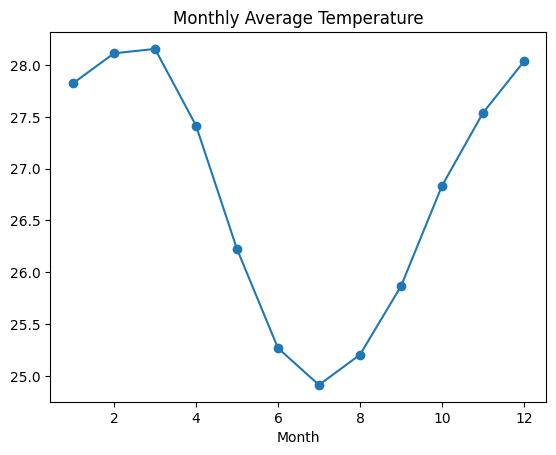

In [12]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line", marker="o")
plt.title("Monthly Average Temperature")
plt.show()

In [13]:
monthly_temp.idxmax(), monthly_temp.max()
monthly_temp.idxmin(), monthly_temp.min()

(7, 24.91258064516129)

Rainfall Trend

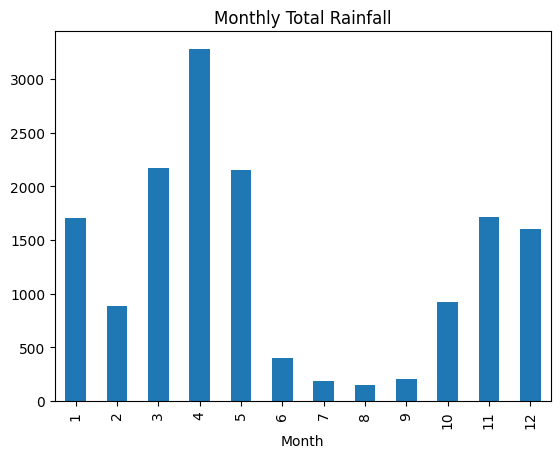

In [14]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall")
plt.show()

Correlation Analysis

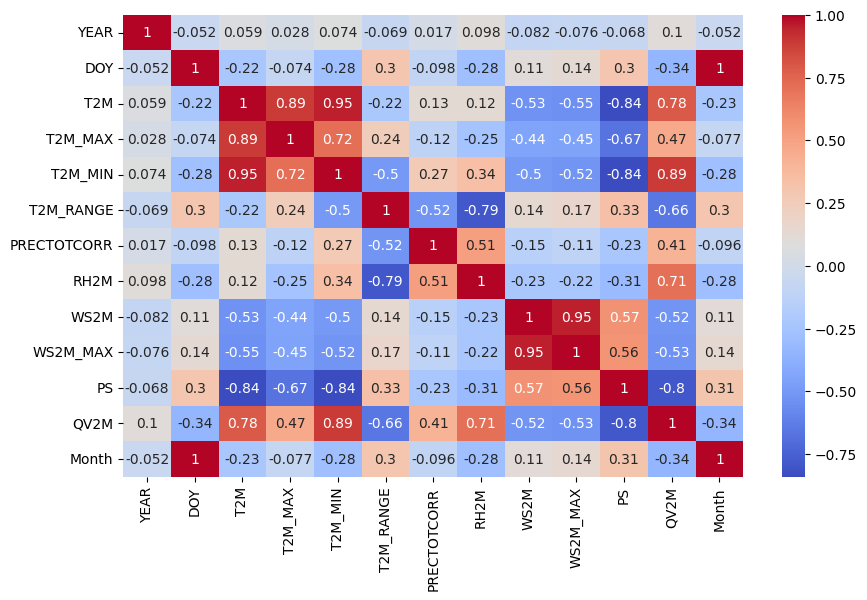

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Scatter plots

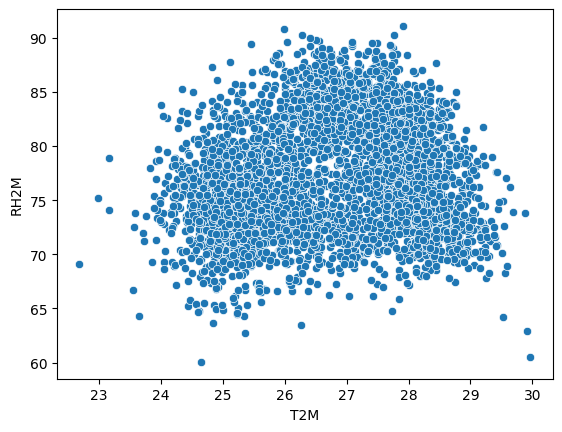

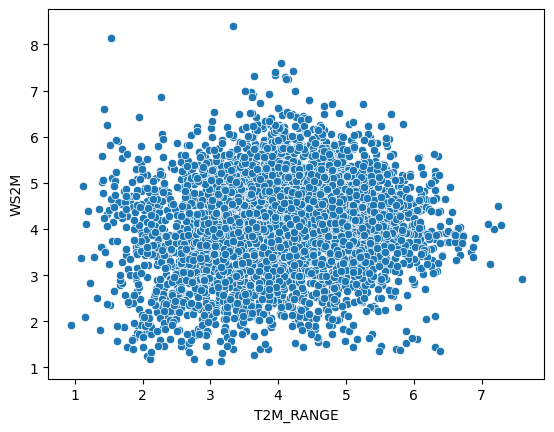

In [16]:
sns.scatterplot(x=df["T2M"], y=df["RH2M"])
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])
plt.show()

Distribution Analysis

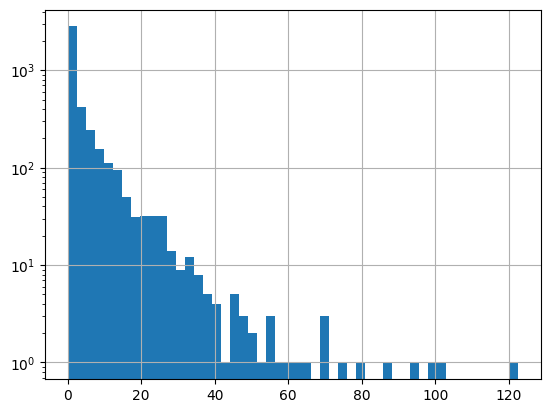

In [17]:
df["PRECTOTCORR"].hist(bins=50)
plt.yscale("log")  # if skewed
plt.show()

Bubble Chart

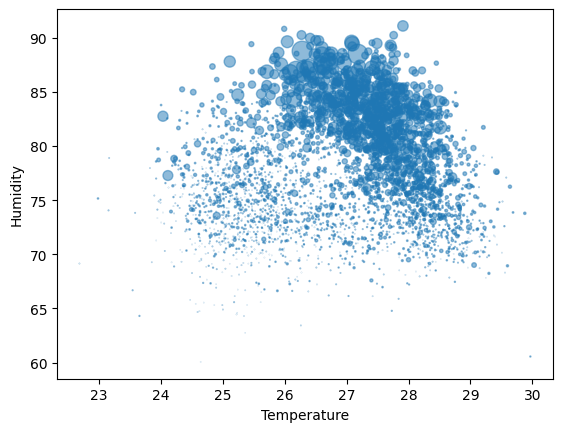

In [18]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*2,
    alpha=0.5
)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()